In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_hub as hub

In [3]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bernardomoraes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df_true = pd.read_csv("True.csv")
df_true = df_true.drop(['subject', 'date'], axis=1)
df_true['label'] = 1
df_true.head()

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [5]:
df_fake = pd.read_csv("Fake.csv")
df_fake = df_fake.drop(['subject', 'date'], axis=1)
df_fake['label'] = 0
df_fake.head()

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0


In [6]:
df = pd.concat([df_true, df_fake], axis=0, ignore_index = True)
df.head()
df.shape

(44898, 3)

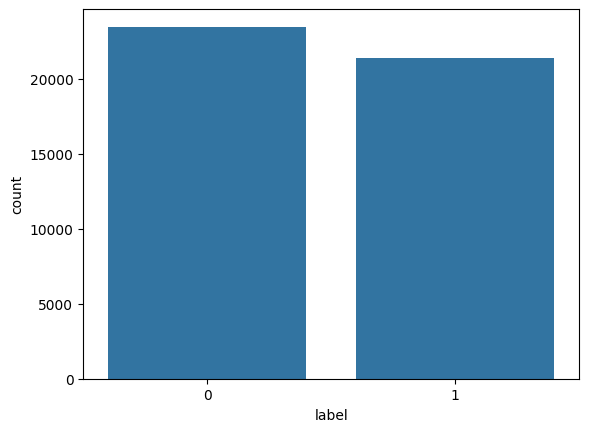

In [7]:
sns.countplot(data=df, x='label')
plt.show()


In [8]:
true_news = df[df['label'] == 1]
fake_news = df[df['label'] == 0]

fake_news_balanced = fake_news.sample(n=len(true_news), random_state=42)

df = pd.concat([true_news, fake_news_balanced]).reset_index(drop=True)
df.shape

(42834, 3)

In [9]:
def remove_stopwords(text):
  stop_words = stopwords.words('english')

  imp_words = []

  for word in text.split():
    word = word.lower()

    if word not in stop_words:
      imp_words.append(word)

  output = " ".join(imp_words)
  return output

df['title'] = df['title'].apply(lambda text: remove_stopwords(text))
df.head()

,title,text,label
0,"u.s. budget fight looms, republicans flip fisc...",WASHINGTON (Reuters) - The head of a conservat...,1
1,u.s. military accept transgender recruits mond...,WASHINGTON (Reuters) - Transgender people will...,1
2,senior u.s. republican senator: 'let mr. muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,fbi russia probe helped australian diplomat ti...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,trump wants postal service charge 'much more' ...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [10]:
total_len = len(df['title'])
sum_len = 0
for i in df['title']:
  i = i.split()
  sum_len += len(i)
average_text_len = round(sum_len / total_len)

X_train, X_test, y_train, y_test = train_test_split(
  df['title'],
  df['label'],
  test_size = 0.2,
  random_state = 42
)

X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
  max_tokens = 10000,
  standardize = 'strip_punctuation',
  output_mode = 'int',
  output_sequence_length = average_text_len
)

text_vec.adapt(X_train_np)

In [11]:
def compile_and_fit(model, epochs=5):
  model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
  )

  history = model.fit(
    X_train_np,
    y_train_np,
    epochs = epochs,
    validation_data = (X_test_np, y_test_np)
  )

  return history


def get_metrics(model, X, y):
  y_preds = np.round(model.predict(X))
  return {
    'Accuracy': accuracy_score(y,y_preds),
    'Precision': precision_score(y,y_preds),
    'Recall': recall_score(y,y_preds),
    'F1-Score': f1_score(y,y_preds)
  }

In [12]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=10000, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name='Dense_Model')
history_1 = compile_and_fit(model_1)

Epoch 1/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9303 - loss: 0.1903 - val_accuracy: 0.9499 - val_loss: 0.1296
Epoch 2/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9702 - loss: 0.0799 - val_accuracy: 0.9491 - val_loss: 0.1342
Epoch 3/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9816 - loss: 0.0529 - val_accuracy: 0.9504 - val_loss: 0.1481
Epoch 4/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9868 - loss: 0.0389 - val_accuracy: 0.9481 - val_loss: 0.1710
Epoch 5/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9892 - loss: 0.0310 - val_accuracy: 0.9482 - val_loss: 0.1866


In [13]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=10000, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(input_layer, output_layer, name='BiLSTM_Model')
history_2 = compile_and_fit(model_2)

Epoch 1/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - accuracy: 0.9387 - loss: 0.1569 - val_accuracy: 0.9555 - val_loss: 0.1128
Epoch 2/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.9797 - loss: 0.0576 - val_accuracy: 0.9561 - val_loss: 0.1147
Epoch 3/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.9897 - loss: 0.0306 - val_accuracy: 0.9532 - val_loss: 0.1264
Epoch 4/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.9942 - loss: 0.0175 - val_accuracy: 0.9527 - val_loss: 0.1552
Epoch 5/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.9961 - loss: 0.0120 - val_accuracy: 0.9546 - val_loss: 0.2042


In [16]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)

input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(x), output_shape=(512,))(input_layer)
x = layers.Dense(64, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_3 = keras.Model(input_layer, output_layer, name='USE_Model')
history_3 = compile_and_fit(model_3)

Epoch 1/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8920 - loss: 0.2672 - val_accuracy: 0.9115 - val_loss: 0.2200
Epoch 2/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9138 - loss: 0.2118 - val_accuracy: 0.9156 - val_loss: 0.2112
Epoch 3/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9177 - loss: 0.1999 - val_accuracy: 0.9181 - val_loss: 0.2032
Epoch 4/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9224 - loss: 0.1895 - val_accuracy: 0.9202 - val_loss: 0.1964
Epoch 5/5
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9258 - loss: 0.1801 - val_accuracy: 0.9195 - val_loss: 0.1932


In [17]:
results = {
  'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
  'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
  'Transfer Learning': get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print('Performance Table:')
print(results_df)

268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step
268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Performance Table:
                   Accuracy  Precision    Recall  F1-Score
Dense Embedding    0.948173   0.946977  0.949627  0.948300
Bi-LSTM            0.954593   0.947030  0.963153  0.955024
Transfer Learning  0.919458   0.912994  0.927472  0.920176
